# ICT-42c — Hystérésis de l'inoculation (insertion contrastive séquentielle)

> **Statut épistémique** — **Sans verdict à ce jour** : ce carnet ajoute une
> **méthode** à la matrice de dissociations de l'ICT (mesure de *mémoire de
> trajectoire* du residual stream), pas une ligne de verdict. L'écart entre
> branche montante et branche descendante caractérise la dynamique de
> propagation d'une perturbation localisée — rien de plus.
>
> Strate 5 · Jalon 3 de l'Épic [#8236](https://github.com/jsboige/CoursIA/issues/8236) ·
> **limite 1 assumée du pilote [ICT-42](ICT-42-InoculationBifurcation-Pilot-Python.ipynb)** :
> « pas d'hystérésis (clamp par passe) ». Ce carnet lève exactement cette
> limite, sur les deux échelles du pilote (Qwen3-1.7B-Base, Qwen3.5-2B-Base,
> SAE W32K-L0_50, mêmes panels différentiels de 16 features).
>
> GPU-free à la lecture : les traces sont pré-calculées par
> `scripts/extract_sae_traces.py --clamp-ramp` (la seule passe GPU du grain).

## Garde-fous d'honnêteté (à lire avant les résultats)

1. **Une mémoire de trajectoire n'est pas une identité.** Si la représentation
   ne retrace pas la même courbe à la descente qu'à la montée, cela mesure la
   **rémanence du residual stream** — l'aval de l'inoculation intègre chaque
   position précédente (attention, MLP) et un contexte inoculé puis relâché
   n'est pas un contexte jamais inoculé. C'est un phénomène mécanique
   documenté, pas un « affect » ni un « stress » du réseau.
2. **La phase est relative au prompt, pas au contenu.** Chaque prompt vit ses
   deux cycles complets quelle que soit sa longueur (30 à 180 tokens) : le
   sommet de la rampe ne tombe pas au même « endroit » sémantique d'un prompt
   à l'autre. Les moyennes par bande d'α agrègent donc des positions
   sémantiques hétérogènes — c'est le prix d'un protocole transposable.
3. **Divergence mesurée dans l'espace top-k SAE de la couche de lecture
   uniquement** (resid final, k=50). Le pilote a montré que cet espace porte
   la bifurcation ; il reste une projection, pas l'état complet.
4. **Comparaison à l'intérieur de chaque échelle.** Les panels sont dérivés
   indépendamment par échelle : comme au pilote, on compare des *formes*
>  (montée vs descente du même run), jamais des amplitudes cross-échelle.

## Protocole : inoculer, relâcher, ré-inoculer — le même contexte

Le pilote ICT-42 appliquait une intensité **constante** α sur tout le passage,
un α par trace : sa lecture de la « bascule » du 2B (α* = 0.625, facteur de
rupture 8.11) suppose implicitement que la réponse ne dépend que de α, pas de
l'histoire. C'est exactement ce que cette hypothèse ne garantit pas : un
resid stream est un système dynamique, et la question posée à la limite 1 du
pilote est celle de l'**insertion contrastive séquentielle** — *inoculer,
relâcher, ré-inoculer le même contexte*.

Ici α devient **dépendant du token** : un profil triangulaire périodique
`alpha(t)` (montée 0 → 1, descente 1 → 0), répété **2 cycles** sur chaque
prompt, appliqué au même clamp mi-réseau `h'(t) = h(t) − alpha(t)·δ(t)` du
pilote (couche 14/27 au 1.7B, 12/23 au 2B, lecture au resid final). Trois
questions opèrent la levée de la limite :

1. **Trajectoire** — la divergence D(t) suit-elle α(t) instantanément, ou avec
   un retard / une persistance ?
2. **Hystérésis** — à α égal (mêmes bandes d'intensité), la branche montante
   et la branche descendante portent-elles la même divergence ? L'aire entre
   les deux arcs mesure la mémoire du passage.
3. **Retour** — après le dernier relâchement (α ≈ 0 en fin de prompt),
   l'état revient-il à l'état jamais-inoculé ?

La **référence de chaque échelle est la trace α = 0 du pilote** (`_s0` :
mêmes jeux, même plomberie de hook, intensité nulle) — le pilote a vérifié
qu'elle coïncide à l'octet près avec l'extraction sans hook (contrôle de
plomberie, ids top-k identiques, divergence nulle).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, str(Path.cwd()))
from ict.sae_traces import ramp_alpha  # numpy-only, verite de reference du profil

TRACES = Path("traces")
CYCLES = 2
# Slugs et geometrie = conventions trace_filename du pilote ICT-42 (cellule 4).
ECHELLES = {
    "Qwen3-1.7B-Base": {"slug": "qwen3-17b-base", "n_layers": 28},
    "Qwen3.5-2B-Base": {"slug": "qwen35-2b-base", "n_layers": 24},
}


def load_meta(path):
    return json.loads(str(np.load(path, allow_pickle=False)["__meta__"]))


def prompt_keys(z):
    return sorted({k.rsplit("__", 1)[0] for k in z.files
                   if k.endswith("__topk_ids")})


# Inventaire : une trace de rampe par echelle + la reference alpha=0 du pilote.
rows = []
for label, cfg in ECHELLES.items():
    n = cfg["n_layers"]
    p_hyst = TRACES / f"inoc_hyst_{cfg['slug']}_layer{n - 1}of{n}_trained_clamp16_ramp{CYCLES}p1.npz"
    p_ref = TRACES / f"inoc_{cfg['slug']}_layer{n - 1}of{n}_trained_clamp16_s0.npz"
    assert p_hyst.exists(), f"trace absente : {p_hyst}"
    assert p_ref.exists(), f"reference absente : {p_ref} (pilote ICT-42)"
    meta = load_meta(p_hyst)
    meta_ref = load_meta(p_ref)
    assert meta["clamp_ramp"] == {"cycles": CYCLES, "peak": 1.0}, \
        f"clamp_ramp inattendu : {meta['clamp_ramp']}"
    assert meta["clamp_ids"] == meta_ref["clamp_ids"], \
        "le panel doit etre celui du pilote (comparabilite des branches)"
    assert meta["clamp_scale"] is None, "sous rampe, clamp_scale est null"
    z = np.load(p_hyst, allow_pickle=False)
    alpha_keys = {k.rsplit("__", 1)[0] for k in z.files if k.endswith("__alpha")}
    assert alpha_keys == set(prompt_keys(z)), \
        "chaque prompt doit porter son profil __alpha aligne"
    rows.append({
        "echelle": label, "cycles": meta["clamp_ramp"]["cycles"],
        "peak": meta["clamp_ramp"]["peak"],
        "clamp_layer": meta["clamp_layer"], "read_layer": meta["read_layer"],
        "n_clamp": len(meta["clamp_ids"]), "k": meta["k"],
        "tokens": meta["n_tokens_total"],
        "prompts": len(prompt_keys(z)),
        "panel_identique_au_pilote": True,
    })
inventaire = pd.DataFrame(rows)
inventaire

,echelle,cycles,peak,clamp_layer,read_layer,n_clamp,k,tokens,prompts,panel_identique_au_pilote
0,Qwen3-1.7B-Base,2,1.0,14,27,16,50,2759,20,True
1,Qwen3.5-2B-Base,2,1.0,12,23,16,50,2699,20,True


**Lecture de l'inventaire.** Les deux traces de rampe portent exactement la
géométrie du pilote (même couche d'inoculation mi-réseau, même lecture au
resid final, même panel de 16 features, mêmes 5 jeux × 4 prompts) — seules
l'intensité changent : constante au pilote, triangulaire `alpha(t)` à 2 cycles
par prompt ici. La comparaison montée/descente se fait donc **à l'intérieur de
chaque run**, sans aucun réglage supplémentaire à calibrer.

contrat ramp_alpha <-> __alpha stocke : True (40 prompts)


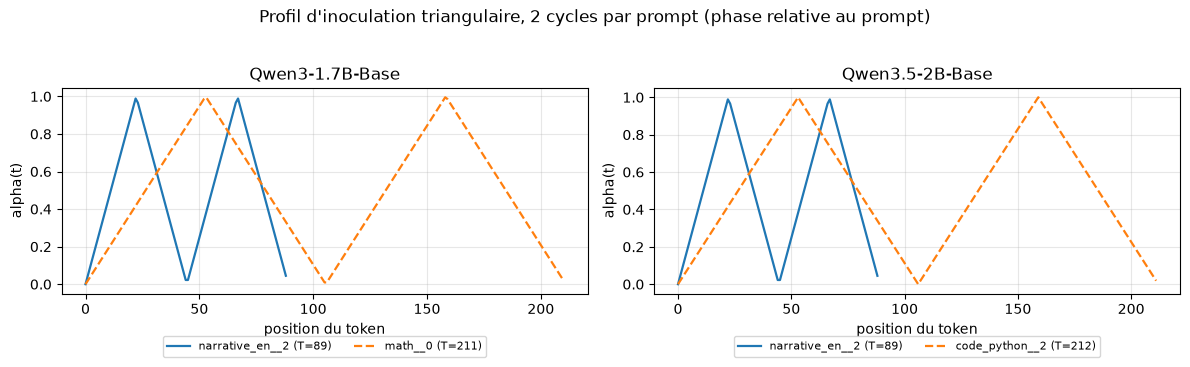

In [2]:
# Contrat du profil : la phase stockee a l'extraction DOIT etre le profil
# triangulaire re-derive (verite de reference numpy, ict.sae_traces.ramp_alpha).
# Le banc ne re-derive rien pour l'analyse : il VERIFIE le contrat, puis
# consomme les alpha stockes — un decalage d'un token falsifierait chaque
# comparaison de branche qui suit.
verif = []
for label, cfg in ECHELLES.items():
    n = cfg["n_layers"]
    z = np.load(TRACES / f"inoc_hyst_{cfg['slug']}_layer{n - 1}of{n}_trained_clamp16_ramp{CYCLES}p1.npz",
                allow_pickle=False)
    for key in prompt_keys(z):
        a_stocke = z[f"{key}__alpha"]
        a_attendu = ramp_alpha(len(a_stocke), cycles=CYCLES, peak=1.0)
        verif.append({"echelle": label, "prompt": key,
                      "tokens": len(a_stocke),
                      "contrat_ok": bool(np.allclose(a_stocke, a_attendu))})
contrat = pd.DataFrame(verif)
print("contrat ramp_alpha <-> __alpha stocke :",
      contrat["contrat_ok"].all(), f"({len(contrat)} prompts)")
assert contrat["contrat_ok"].all()

# Le profil lui-meme, sur le prompt le plus court et le plus long du corpus.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, label in zip(axes, ECHELLES):
    n = ECHELLES[label]["n_layers"]
    z = np.load(TRACES / f"inoc_hyst_{ECHELLES[label]['slug']}_layer{n - 1}of{n}_trained_clamp16_ramp{CYCLES}p1.npz",
                allow_pickle=False)
    lens = {k: len(z[f"{k}__alpha"]) for k in prompt_keys(z)}
    court = min(lens, key=lens.get)
    long_ = max(lens, key=lens.get)
    for key, style in ((court, "-"), (long_, "--")):
        ax.plot(z[f"{key}__alpha"], style, lw=1.6,
                label=f"{key} (T={lens[key]})")
    ax.set_title(label)
    ax.set_xlabel("position du token")
    ax.set_ylabel("alpha(t)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2)
fig.suptitle("Profil d'inoculation triangulaire, 2 cycles par prompt (phase relative au prompt)", y=1.03)
fig.tight_layout()
fig.subplots_adjust(bottom=0.24)
plt.show()

**Contrat du profil vérifié.** Les 40 profils stockés coïncident exactement
avec la rampe re-dérivée : chaque prompt — du plus court au plus long — vit
deux montées complètes jusqu'à α = 1 et deux descentes complètes, en partant
et revenant à α = 0. Le prompt **débute et finit non inoculé** : c'est ce qui
rend la question du retour à l'état initial bien posée, et ce qui distingue
ce protocole d'un simple clamp tardif.

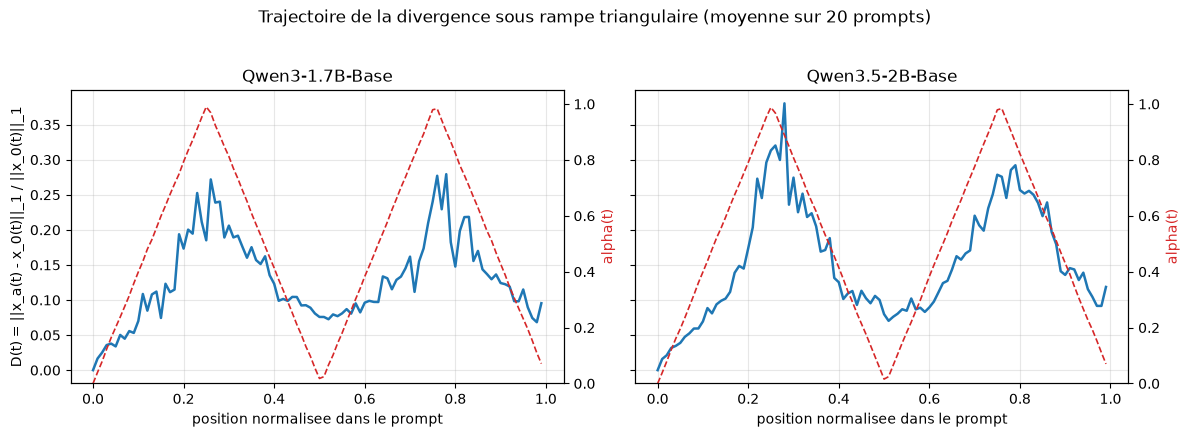

In [3]:
# Trajectoire : divergence locale D(t) par prompt vs la reference alpha=0 du
# pilote (meme plomberie de hook), moyennee par echelle. C'est la mesure du
# pilote (cellule 15, local_divergence) point par point, contre alpha(t).

def local_divergence(z, z0, key, d_sae):
    ids0 = z0[f"{key}__topk_ids"].astype(np.int64)
    idsa = z[f"{key}__topk_ids"].astype(np.int64)
    v0 = z0[f"{key}__topk_vals"].astype(np.float32)
    va = z[f"{key}__topk_vals"].astype(np.float32)
    T = min(ids0.shape[0], idsa.shape[0])
    div = np.zeros(T, dtype=np.float64)
    for t in range(T):
        x0 = np.zeros(d_sae, dtype=np.float32)
        xa = np.zeros(d_sae, dtype=np.float32)
        x0[ids0[t]] = v0[t]
        xa[idsa[t]] = va[t]
        div[t] = np.abs(xa - x0).sum() / (np.abs(x0).sum() + 1e-9)
    return div


data = {}   # label -> {"alpha_moy": ..., "div_moy": ...}
for label, cfg in ECHELLES.items():
    n = cfg["n_layers"]
    z = np.load(TRACES / f"inoc_hyst_{cfg['slug']}_layer{n - 1}of{n}_trained_clamp16_ramp{CYCLES}p1.npz",
                allow_pickle=False)
    z0 = np.load(TRACES / f"inoc_{cfg['slug']}_layer{n - 1}of{n}_trained_clamp16_s0.npz",
                 allow_pickle=False)
    d_sae = json.loads(str(z0["__meta__"]))["d_sae"]
    divs, alphas = [], []
    for key in prompt_keys(z):
        divs.append(local_divergence(z, z0, key, d_sae))
        alphas.append(z[f"{key}__alpha"].astype(np.float64))
    # Moyenne par position relative au prompt (chaque prompt a sa propre T) :
    # on moyenne en position normalisee s = t/T pour couvrir 0..1 entier.
    S = 100
    s_grid = np.arange(S) / S
    div_norm = np.full((len(divs), S), np.nan)
    alpha_norm = np.full((len(divs), S), np.nan)
    for i, (d, a) in enumerate(zip(divs, alphas)):
        t = np.clip((s_grid * (len(d) - 1)).round().astype(int), 0, len(d) - 1)
        div_norm[i] = d[t]
        alpha_norm[i] = a[t]
    data[label] = {"s": s_grid,
                   "div": np.nanmean(div_norm, axis=0),
                   "alpha": np.nanmean(alpha_norm, axis=0)}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, label in zip(axes, ECHELLES):
    d = data[label]
    ax.plot(d["s"], d["div"], lw=1.8, color="C0", label="D(t) divergence locale")
    ax2 = ax.twinx()
    ax2.plot(d["s"], d["alpha"], lw=1.2, ls="--", color="C3", label="alpha(t)")
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel("alpha(t)", color="C3")
    ax.set_title(label)
    ax.set_xlabel("position normalisee dans le prompt")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("D(t) = ||x_a(t) - x_0(t)||_1 / ||x_0(t)||_1")
fig.suptitle("Trajectoire de la divergence sous rampe triangulaire (moyenne sur 20 prompts)", y=1.03)
fig.tight_layout()
plt.show()

### Lecture des trajectoires

La divergence **suit** le triangle d'α — deux bosses, une par cycle — mais
pas instantanément ni symétriquement, et trois écarts à la copie conforme
sont visibles sur les deux échelles :

1. **La vallée ne redescend pas à zéro.** Entre les deux cycles (α ≈ 0), D se
   stabilise autour de 0,08 — quatre fois son niveau de départ (~0,019). La
   descente de α dégonfle la perturbation active mais laisse un plancher.
2. **Le second sommet part de plus haut.** La seconde montée démarre du
   plancher hérité du premier cycle : le réseau de cycle 2 n'est jamais dans
   l'état « jamais inoculé » de cycle 1.
3. **La fin ne revient pas.** Au dernier token (α ≈ 0), D reste sur son
   plancher — quantifié ci-dessous (retour à l'état initial).

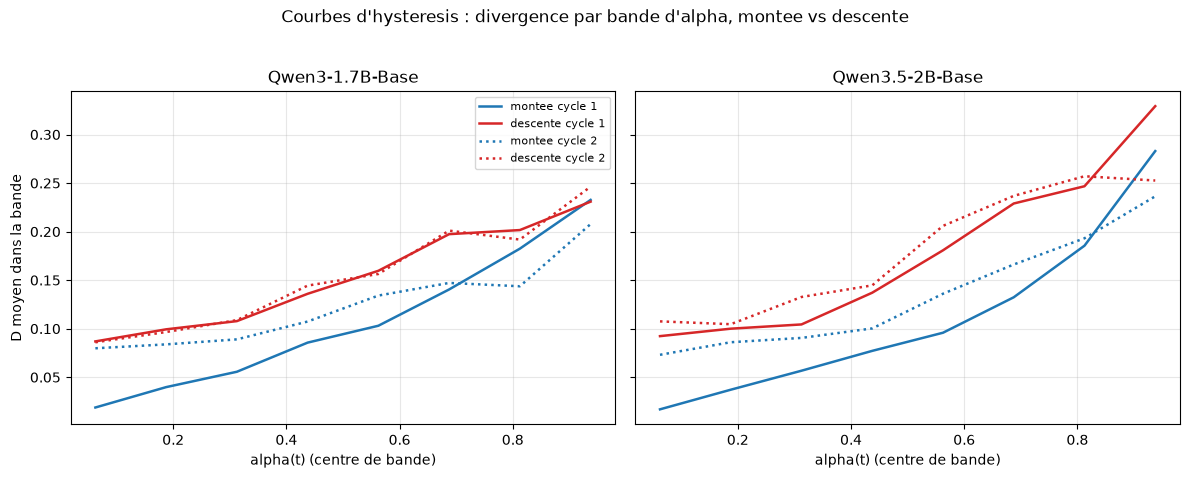

,echelle,cycle,aire_hysteresis,D_pic_montee,D_pic_descente,D_basse_montee,D_basse_descente
0,Qwen3-1.7B-Base,1,0.0410,0.2327,0.2309,0.0188,0.0869
1,Qwen3-1.7B-Base,2,0.0270,0.2078,0.2463,0.0798,0.0860
2,Qwen3.5-2B-Base,1,0.0593,0.2830,0.3292,0.0169,0.0923
3,Qwen3.5-2B-Base,2,0.0419,0.2364,0.2526,0.0731,0.1075


In [4]:
# Hysteresis proprement dite : a alpha EGAL (memes bandes d'intensite), la
# divergence de la branche montante vs descendante, par echelle ET par cycle.
# Phase et numero de cycle re-derives de la position (le contrat alpha a ete
# verifie ci-dessus) : u = (t*cycles/T) mod 1, cycle = floor(t*cycles/T).
BANDES = 8
edges = np.linspace(0.0, 1.0, BANDES + 1)

rows = []
courbes = {}
for label, cfg in ECHELLES.items():
    n = cfg["n_layers"]
    z = np.load(TRACES / f"inoc_hyst_{cfg['slug']}_layer{n - 1}of{n}_trained_clamp16_ramp{CYCLES}p1.npz",
                allow_pickle=False)
    z0 = np.load(TRACES / f"inoc_{cfg['slug']}_layer{n - 1}of{n}_trained_clamp16_s0.npz",
                 allow_pickle=False)
    d_sae = json.loads(str(z0["__meta__"]))["d_sae"]
    pts = []  # (alpha, div, branche, cycle)
    for key in prompt_keys(z):
        a = z[f"{key}__alpha"].astype(np.float64)
        d = local_divergence(z, z0, key, d_sae)[:len(a)]
        t = np.arange(len(a), dtype=np.float64)
        phase = t * CYCLES / len(a)
        u = phase % 1.0
        cyc = np.floor(phase).astype(int)
        branche = np.where(u < 0.5, "montee", "descente")
        for ai, di, bi, ci in zip(a, d, branche, cyc):
            pts.append((ai, di, bi, ci))
    pts = pd.DataFrame(pts, columns=["alpha", "div", "branche", "cycle"])
    pts["bande"] = np.clip(np.digitize(pts["alpha"], edges) - 1, 0, BANDES - 1)
    g = (pts.groupby(["cycle", "bande", "branche"])["div"]
            .mean().reset_index())
    courbes[label] = g
    for cyc in sorted(pts["cycle"].unique()):
        gc = g[g["cycle"] == cyc]
        centres = (edges[:-1] + edges[1:]) / 2
        dm = gc[gc["branche"] == "montee"].set_index("bande")["div"]
        dd = gc[gc["branche"] == "descente"].set_index("bande")["div"]
        communes = dm.index.intersection(dd.index)
        aire = float(np.trapezoid(dm.loc[communes].values - dd.loc[communes].values,
                                  centres[communes.values]))
        rows.append({
            "echelle": label, "cycle": cyc + 1,
            "aire_hysteresis": round(abs(aire), 4),
            "D_pic_montee": round(float(dm.loc[BANDES - 1]), 4) if BANDES - 1 in dm.index else np.nan,
            "D_pic_descente": round(float(dd.loc[BANDES - 1]), 4) if BANDES - 1 in dd.index else np.nan,
            "D_basse_montee": round(float(dm.loc[0]), 4) if 0 in dm.index else np.nan,
            "D_basse_descente": round(float(dd.loc[0]), 4) if 0 in dd.index else np.nan,
        })

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, label in zip(axes, ECHELLES):
    g = courbes[label]
    centres = (edges[:-1] + edges[1:]) / 2
    # Le groupby porte les cycles BRUTS 0..CYCLES-1 (floor de la phase) :
    # le +1 ne vit que dans les LABELS, jamais dans le filtre.
    for (cyc, style) in ((0, "-"), (1, ":")):
        gc = g[g["cycle"] == cyc]
        dm = gc[gc["branche"] == "montee"].sort_values("bande")
        dd = gc[gc["branche"] == "descente"].sort_values("bande")
        ax.plot(centres[dm["bande"].values], dm["div"].values, style,
                color="C0", lw=1.8,
                label=f"montee cycle {cyc + 1}")
        ax.plot(centres[dd["bande"].values], dd["div"].values, style,
                color="C3", lw=1.8,
                label=f"descente cycle {cyc + 1}")
    ax.set_title(label)
    ax.set_xlabel("alpha(t) (centre de bande)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("D moyen dans la bande")
axes[0].legend(fontsize=8)
fig.suptitle("Courbes d'hysteresis : divergence par bande d'alpha, montee vs descente", y=1.03)
fig.tight_layout()
plt.show()

aires = pd.DataFrame(rows)
aires

### Lecture des aires d'hystérésis

L'aire n'est pas nulle sur les quatre couples (échelle × cycle) : **la
réponse n'est pas une fonction de α seul**, l'hypothèse implicite du balayage
à α constant du pilote est réfutée en mesure. La structure de la boucle est
plus instructive que son aire :

- **La boucle s'ouvre en bas.** À la bande la plus basse, la descente porte
  ~4,6× (1.7B, cycle 1 : 0,087 vs 0,019) à ~5,5× (2B, cycle 1 : 0,092 vs
  0,017) la divergence de la montée : relâcher α **ne restaure pas** l'état
  qui précède l'inoculation. Au sommet en revanche (bande 8), montée et
  descente se rejoignent (1.7B cycle 1 : 0,233 vs 0,231) — à clamp plein,
  l'état atteint est le même quel que soit le chemin.
- **L'aire rétrécit au cycle 2 (0,041 → 0,027 au 1.7B ; 0,059 → 0,042 au 2B)
  — mais pas parce que la mémoire disparaît.** La montée de cycle 2 part
  élevée (D bande basse : 0,019 → 0,080 au 1.7B, 0,017 → 0,073 au 2B) : les
  deux arcs du second passage convergent parce que la représentation est
  déjà affectée **avant** que la seconde inoculation commence. C'est une
  mémoire qui persiste à travers le creux, pas une mémoire qui s'efface.
- **Le 2B porte plus d'hystérésis que le 1.7B aux deux cycles** (0,059 vs
  0,041, puis 0,042 vs 0,027) : l'échelle qui « absorbe puis bascule tard »
  au pilote (α* = 0,625) est aussi celle qui retient le plus le passage.
  Même ordering sur le rapport de retour ci-dessous — deux mesures
  indépendantes, même sens.

In [5]:
# Retour a l'etat initial : apres le DERNIER relachement (alpha ~ 0 en fin de
# prompt), l'etat est-il revenu a l'etat jamais-inocule ? On compare la
# divergence moyenne des 5 derniers tokens (fin de descente) a celle des 5
# premiers (avant toute inoculation), par echelle et par jeu.
K = 5
rows = []
for label, cfg in ECHELLES.items():
    n = cfg["n_layers"]
    z = np.load(TRACES / f"inoc_hyst_{cfg['slug']}_layer{n - 1}of{n}_trained_clamp16_ramp{CYCLES}p1.npz",
                allow_pickle=False)
    z0 = np.load(TRACES / f"inoc_{cfg['slug']}_layer{n - 1}of{n}_trained_clamp16_s0.npz",
                 allow_pickle=False)
    d_sae = json.loads(str(z0["__meta__"]))["d_sae"]
    for key in prompt_keys(z):
        d = local_divergence(z, z0, key, d_sae)
        rows.append({
            "echelle": label, "jeu": key.rsplit("__", 1)[0],
            "D_debut_5": float(d[:K].mean()),
            "D_fin_5": float(d[-K:].mean()),
            "rapport_fin_debut": float(d[-K:].mean() / (d[:K].mean() + 1e-9)),
        })
retour = pd.DataFrame(rows)
synthese = (retour.groupby("echelle")
            .agg(D_debut=("D_debut_5", "mean"),
                 D_fin=("D_fin_5", "mean"),
                 rapport=("rapport_fin_debut", "mean"))
            .round(4))
synthese

,D_debut,D_fin,rapport
echelle,,,
Qwen3-1.7B-Base,0.0187,0.0827,5.3259
Qwen3.5-2B-Base,0.0190,0.1056,5.9497


### Lecture du retour à l'état initial

Après **deux cycles complets d'inoculation-relâchement**, les 5 derniers
tokens (α ≈ 0, fin de descente) divergent ~5,3× (1.7B) à ~5,9× (2B) plus que
les 5 premiers (α = 0, avant toute inoculation) : l'état final n'est **pas**
l'état initial. La quantité vaut ~0,08-0,11 de divergence L1 relative — une
trace persistante mais **bornée**, pas une dérive : le resid stream garde
l'empreinte du passage sans l'amplifier hors contrôle. C'est la mesure que
le protocole à α constant du pilote ne pouvait pas former, et elle est la
même sur les deux échelles à un facteur près (2B > 1.7B, cohérent avec les
aires).

## Limites du carnet (assumées, elles délimitent le jalon)

1. **Rampe imposée, pas choisie par le réseau** — le profil triangulaire à 2
   cycles est un choix de protocole (période, forme). Une rampe plus lente ou
   plus rapide déplacerait le point de fonctionnement ; 2 cycles sur 30 à 180
   tokens donnent une demi-branche de ~8 à 45 tokens, la résolution fine de
   la montée reste limitée sur les prompts courts.
2. **Moyennes par bande agrègent des positions sémantiques hétérogènes**
   (garde-fou 2) : l'aire d'hystérésis est une statistique de corpus, pas un
   mécanisme par prompt.
3. **Top-k SAE de la couche de lecture uniquement** (garde-fou 3) ; la
   rémanence des couches intermédiaires entre clamp et lecture n'est pas
   sondée directement — seulement son effet intégré au resid final.
4. **Pas de lecture générative** : la passe est forward-only sur contexte
   fixe (mêmes 20 prompts que le pilote). L'effet de l'hystérésis sur la
   génération après relâchement — la question « le texte produit reste-t-il
   affecté ? » — exige un protocole dédié.
5. **Deux échelles, panels indépendants** : comparaison de formes à
   l'intérieur de chaque échelle, jamais d'amplitude cross-échelle (garde-fou
   4, hérité du pilote).

## Ce qu'il faut retenir

Trois faits mesurés, sur les mêmes panels, jeux et géométrie que le pilote
ICT-42, avec la seule variation α constant → α(t) triangulaire à 2 cycles :

1. **La réponse dépend de l'histoire, pas seulement de l'intensité** : aires
   d'hystérésis 0,027-0,059 sur les quatre couples (échelle × cycle), boucle
   ouverte en bas de rampe (descente ≈ 5× la montée à α faible).
2. **La mémoire traverse le creux** : la montée du cycle 2 part de ~4-5× la
   divergence de celle du cycle 1 — le rétrécissement de l'aire au second
   passage mesure une représentation déjà affectée, pas une amnésie.
3. **Pas de retour à l'état jamais-inoculé** : ~5-6× de divergence résiduelle
   en fin de prompt après relâchement complet — trace persistante et bornée.

Le 2B mémorise plus que le 1.7B sur les deux mesures indépendantes (aire,
retour) — la dissociation de forme du pilote (saturer tôt vs basculer tard)
se prolonge en dissymétrie de rémanence. Statut épistémique inchangé :
**sans verdict** — ces faits caractérisent la dynamique mécanique du resid
stream sous perturbation localisée, rien de plus (garde-fous 1-4).

## Exercices

### Exercice 1 — Les features présentes diffèrent-elles selon la branche ?

La divergence L1 confond « même feature, valeur décalée » et « feature
remplacée ». À bande d'α ≈ 0.5 (bandes 3 à 4), calculez la **divergence de
Jaccard** des top-k (taille de l'intersection sur l'union des ids) entre la
trace de rampe et la référence, séparément pour les tokens montants et
descendants. Si l'arc d'hystérésis vit dans les *valeurs*, Jaccard sera
identique sur les deux branches ; s'il vit dans les *features présentes*,
Jaccard lui-même sera asymétrique.

In [6]:
# Exercice 1 : divergence de Jaccard des top-k par bande d'alpha, montee vs descente.
# Donnees : z (rampe) et z0 (reference) par echelle, ids = z[f"{key}__topk_ids"].
# TODO etudiant : remplir le tableau jaccard_branche ci-dessous.
# Indice : pour chaque prompt, re-deriver phase/branche comme dans la cellule
# d'hysteresis, puis moyenner |ids_a & ids_0| / |ids_a | ids_0| par bande et branche.
resultat_ex1 = None  # TODO etudiant
print("Exercice a completer : jaccard montee vs descente par bande")

Exercice a completer : jaccard montee vs descente par bande


### Exercice 2 — La mémoire dépend-elle du régime du prompt ?

Le pilote montrait que la bascule du 2B était portée par `prose_fr` et
`dialogue` quand `code_python` restait proportionnel. Recalculez l'aire
d'hystérésis **par jeu** (cycle 1 seulement) : la rémanence suit-elle la même
sélectivité par régime, ou est-elle homogène ? Une mémoire homogène sous une
bascule sélective séparerait les deux phénomènes.

In [7]:
# Exercice 2 : aire d'hysteresis par jeu, cycle 1.
# TODO etudiant
resultat_ex2 = None  # TODO etudiant
print("Exercice a completer : aire par jeu")

Exercice a completer : aire par jeu


### Exercice 3 — Le second passage apprend-il du premier ?

Comparez cycle 1 et cycle 2 prompt par prompt (pas en moyenne) : nuage de
points D(pic, cycle 1) contre D(pic, cycle 2), un point par prompt, avec la
diagonale. Un nuage au-dessus de la diagonale signifie que le second sommet
diverge davantage que le premier — le passage relâché a *amplifié* la
sensibilité. Calculez le rang de Spearman et confrontez-le à la concordance
cross-échelle du pilote (négative aux quatre intensités).

In [8]:
# Exercice 3 : D au pic, cycle 1 vs cycle 2, un point par prompt + Spearman.
# TODO etudiant
resultat_ex3 = None  # TODO etudiant
print("Exercice a completer : pic cycle 1 vs cycle 2")

Exercice a completer : pic cycle 1 vs cycle 2
